Importing modules and loading the dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

df = pd.read_csv('telco_customer_churn.csv')

In [5]:

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


# Exploratory Data Analysis

## 2. Dataset Description
* **How many features?** 19 input features (excluding `customerID` and the target `Churn`).
* **Classification or regression problem?** Classification. We are predicting a categorical label ("Yes" or "No" for Churn), not a continuous number.
* **How many data points?** 7,043 data points.
* **What kind of features are in your dataset?** A mix of Quantitative (e.g., `tenure`, `MonthlyCharges`) and Categorical (e.g., `gender`, `InternetService`, `Contract`).
* **Do you need to encode the categorical variables?** Yes. Machine learning models rely on mathematical equations and cannot process raw text strings like "Fiber Optic" or "Month-to-month". We must encode them into numerical values (0s and 1s) using techniques like Label Encoding and One-Hot Encoding.

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_18988\829261054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


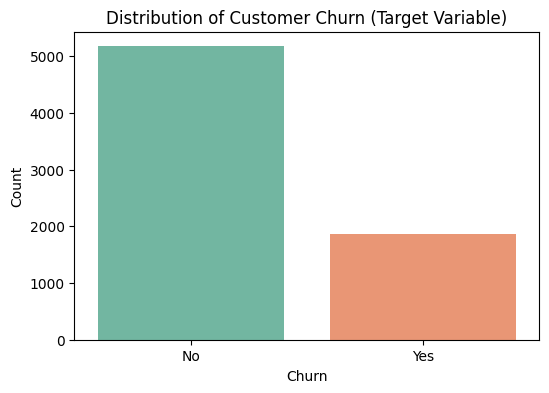

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn (Target Variable)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Print the exact numbers
print(df['Churn'].value_counts())

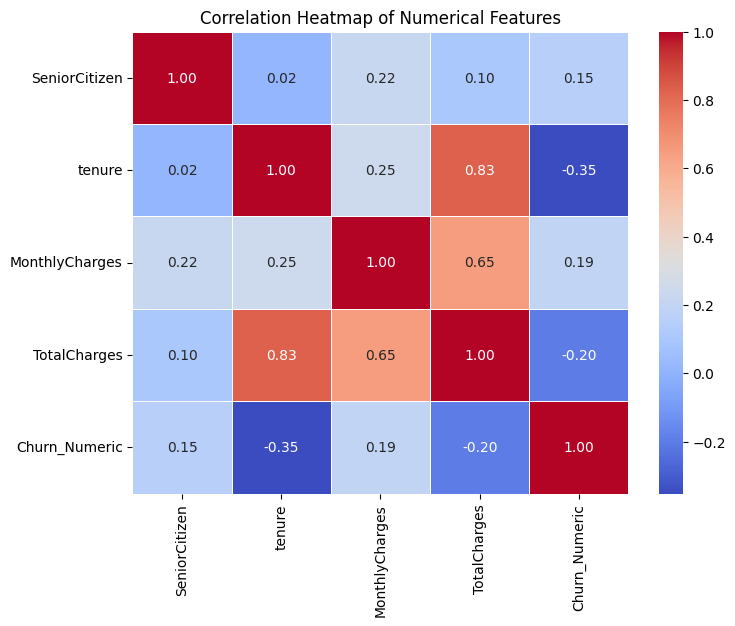

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_18988\4277662832.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


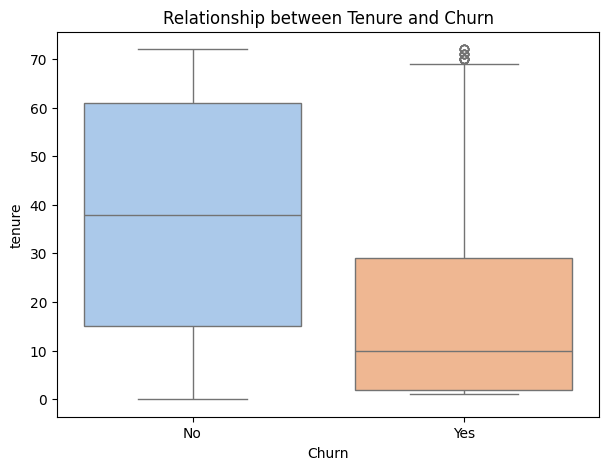

In [7]:
# Create a temporary copy for EDA so we don't mess up our main dataset
df_eda = df.copy()

# 1. Convert TotalCharges to numeric (ignoring errors for now)
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

# Converting Churn to 1s and 0s just for the heatmap
df_eda['Churn_Numeric'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})

# Select only the numeric columns for correlation , it will crash if we include non-numeric columns
numeric_cols = df_eda[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']]

# Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Extract an important relationship (EDA)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Relationship between Tenure and Churn')
plt.show()

### EDA & Correlation Insights:
1. **Tenure and Churn (Negative Correlation):** There is a strong negative correlation between `tenure` and `Churn`. The boxplot confirms this: customers with a lower tenure (newer customers) are far more likely to churn than customers who have been with the company for a long time.
2. **Monthly Charges and Churn (Positive Correlation):** There is a positive correlation between `MonthlyCharges` and `Churn`. Customers who pay higher monthly fees are more likely to cancel their service. 
3. **Total Charges and Tenure (High Multicollinearity):** `TotalCharges` and `tenure` are highly correlated with each other (close to 0.82), which is logical since the longer you stay, the more your total charges accumulate.

### 3. Dataset Pre-processing

#### Problem 1: Null / Missing Values and Useless Features
* **The Fault:** The `TotalCharges` column contains hidden blank spaces (" ") instead of numbers, which machine learning models cannot process. Additionally, the `customerID` column contains random strings that provide no predictive value.
* **The Solution:** We will delete the useless `customerID` column. For `TotalCharges`, we will convert the blanks into `NaN` (Not a Number) and impute (fill) these missing values using the median of the column.

In [8]:

#dropping customerID since it is not useful for modeling

df = df.drop(columns=['customerID'])

# Fixing the total charge columnn by replacing the empty spaces with NaN and then converting it to numeric
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Imputing/ filling the missing values in TotalCharges with the median value
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing values after imputation:", df['TotalCharges'].isnull().sum())



Missing values after imputation: 0


#### Problem 2: Categorical Values
* **The Fault:** Our dataset contains text-based features (e.g., "Yes/No", "Fiber Optic", "Month-to-month"). Machine learning algorithms rely on mathematical equations and cannot read raw text.
* **The Solution:** We will apply **Encoding**. For features with only two unique categories (like `gender` and `Churn`), we will use **Label Encoding** to convert them into 0s and 1s. For features with three or more categories (like `InternetService`), we will use **One-Hot Encoding** to create separate binary columns.

In [9]:
from sklearn.preprocessing import LabelEncoder

#Encoding the categorical variables using LabelEncoder
cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

#Encoding multi-option categorical variables using get_dummies-> encodes each category as a separate binary column
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols , drop_first=True)
print(f"Data shape after encoding: {df.shape}")

Data shape after encoding: (7043, 31)


#### Problem 3: Feature Scaling
* **The Fault:** There is a massive scale difference between our features. For example, `tenure` ranges from 0 to 72, while `TotalCharges` goes up to $8,000+. Distance-based models (like K-Means) and Neural Networks will incorrectly assume that `TotalCharges` is the most important feature just because its numbers are larger.
* **The Solution:** We will apply **MinMaxScaler** to standardize all numerical features, scaling their values down to a proportional range between 0 and 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#Initializing the Scaler

scaler = MinMaxScaler()

#Selecting the numeric columns to be scaled and applying the scaler
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

display(df.head())